# Phenotype phase planes (glucose, and glucose x oxygen)

**Part 1.** M9 medium applied to each model (`iBsu1103`/`iBsu1103v2`/`iBsu1209` excluded), oxygen released, `EX_glc__D_e` scanned from 0 to -15 mmol/gDW/h over 31 points. Writes `../results/tables/PhPP.csv` and `../results/figures/qGlc_vs_mu.pdf`.

**Part 2.** Glucose and oxygen swept together over a grid, all other bounds at their M9 values. Writes `../results/tables/PhPP_3D_grid.csv` and `../results/figures/3d_PhPP/`.

Oxygen is released in Part 1 so that respiration is not throttled independently of the carbon source; it is the scanned variable in Part 2 and so is not released there. The plateau at the top of the Part 1 scan is set by the M9 ammonia cap, not by oxygen or carbon — the audit at the end of the scan cell identifies the binding exchange per model.

In [1]:
import os
import cobra
import numpy as np
import pandas as pd

final_dir = os.path.join("..", "data", "models", "02_final_annotated")
# iBsu1103, iBsu1103v2, iBsu1209 excluded from analysis notebooks 03+ (see PROJECT_CONTEXT.md)
model_names = ["iYO844", "iBsu1147", "eciYO844", "iBB1018", "iBsu1147R", "ecBSU1", "Submodel"]
modelos = {name: os.path.join(final_dir, f"{name}.xml") for name in model_names}

medium = pd.read_csv("../data/datasets/M9_media.csv")

N_POINTS = 31
UPTAKE_MIN, UPTAKE_MAX = 0, -15  # mmol/gDW/h, imposed lower bound on EX_glc__D_e
ZERO_TOL = 1e-9
OXYGEN_EXCHANGE = "EX_o2_e"


def set_culture_media(model, media):
    """Apply the media bounds, closing any `_reverse` import partner.

    GECKO models bypass the medium cap entirely if those partners are left open: ecBSU1 was
    taking up 9.3 mmol/gDW/h of ammonia against an M9 cap of 5.
    """
    for _, row in media.iterrows():
        rxn_id = row["ID"]
        if rxn_id not in model.reactions:
            continue
        model.reactions.get_by_id(rxn_id).bounds = (row["LOWER_BOUND"], row["UPPER_BOUND"])

        reverse_id = f"{rxn_id}_reverse"
        if reverse_id in model.reactions:
            model.reactions.get_by_id(reverse_id).bounds = (0.0, 0.0)
    return model


def release_oxygen(model):
    """Lift the oxygen cap so respiration is not throttled independently of glucose.

    Binding for eciYO844 only; the `_reverse` partner stays closed.
    """
    if OXYGEN_EXCHANGE in model.reactions:
        model.reactions.get_by_id(OXYGEN_EXCHANGE).bounds = (-1000.0, 1000.0)
    return model


def refresh_solver(model):
    """Drop accumulated LP-solver state, keeping the current bounds.

    Long scans degrade the warm start: the solver begins returning status `optimal` with an
    objective of exactly 0 for bounds that do support growth, with no warning. Every zero is
    re-checked on a refreshed problem and the curves are audited for monotonicity.
    """
    problem = getattr(model.solver, "problem", None)
    if hasattr(problem, "reset"):
        problem.reset()
    else:
        model.solver = model.solver.interface


all_results = []

for model_name, model_path in modelos.items():
    print(f"Simulating {model_name}...")
    model = cobra.io.read_sbml_model(model_path)
    set_culture_media(model, medium)
    release_oxygen(model)

    try:
        rxn_glc = model.reactions.get_by_id("EX_glc__D_e")
    except KeyError:
        print(f"  {model_name} has no EX_glc__D_e, skipping")
        continue

    n_infeasible = n_recovered = 0
    for uptake in np.linspace(UPTAKE_MIN, UPTAKE_MAX, N_POINTS):
        with model:
            rxn_glc.lower_bound = uptake
            rxn_glc.upper_bound = 1000

            mu = model.slim_optimize()
            if mu is None or np.isnan(mu) or mu <= ZERO_TOL:
                refresh_solver(model)
                retry = model.slim_optimize()
                if retry is not None and not np.isnan(retry) and retry > ZERO_TOL:
                    n_recovered += 1
                mu = retry

            if mu is None or np.isnan(mu) or mu < 0:
                # No growth possible at this bound; recorded as 0 rather than dropped.
                n_infeasible += 1
                mu = 0.0

            all_results.append({
                "Model": model_name,
                "Glucose_uptake": -uptake,
                "Growth_rate": mu,
            })

    if n_infeasible:
        print(f"  {model_name}: {n_infeasible}/{N_POINTS} bounds were infeasible (growth = 0)")
    if n_recovered:
        print(f"  {model_name}: {n_recovered} stale-solver zeros recovered")

df_results = pd.DataFrame(all_results)

# Growth can only rise as the bound is loosened; a dip past LP tolerance means a bad point.
TOLERANCE_NOISE = 1e-3
print("\nMonotonicity audit:")
for model_name, group in df_results.groupby("Model", sort=False):
    curve = group.sort_values("Glucose_uptake")["Growth_rate"].to_numpy()
    worst = float(np.diff(curve).min())
    if worst >= -TOLERANCE_NOISE:
        verdict = "OK" if worst >= 0 else f"OK (worst dip {worst:.1e}, within LP tolerance)"
    else:
        verdict = f"CHECK - worst dip {worst:.2e} exceeds LP tolerance"
    print(f"  {model_name:<10s} {verdict}")

# Identify the binding medium component by lifting each cap in turn.
print("\nWhat limits growth at the top of the scan (qGlc = 15):")
for model_name, model_path in modelos.items():
    model = cobra.io.read_sbml_model(model_path)
    set_culture_media(model, medium)
    release_oxygen(model)
    if "EX_glc__D_e" not in model.reactions:
        continue
    model.reactions.get_by_id("EX_glc__D_e").bounds = (UPTAKE_MAX, 1000)
    base = model.slim_optimize()

    binding = []
    for _, row in medium.iterrows():
        rxn_id = row["ID"]
        if rxn_id not in model.reactions or row["LOWER_BOUND"] <= -1000 or rxn_id == OXYGEN_EXCHANGE:
            continue
        with model:
            model.reactions.get_by_id(rxn_id).lower_bound = -1000.0
            relaxed = model.slim_optimize()
        if relaxed is not None and not np.isnan(relaxed) and relaxed - base > 1e-4:
            binding.append((rxn_id, relaxed - base))

    binding.sort(key=lambda pair: -pair[1])
    detail = (", ".join(f"{rid} (+{gain:.3f})" for rid, gain in binding) if binding
              else "no medium cap binds - ceiling is internal to the model")
    print(f"  {model_name:<10s} mu = {base:.4f}   binding: {detail}")

os.makedirs("../results/tables", exist_ok=True)

import time
for attempt in range(5):
    try:
        df_results.to_csv("../results/tables/PhPP.csv", index=False)
        break
    except PermissionError:
        if attempt == 4:
            raise
        time.sleep(2)

df_results.head()

Simulating iYO844...


Set parameter Username


Set parameter LicenseID to value 2695449


--------------------------------------------


--------------------------------------------


...

  iBsu1147R  mu = 0.5546   binding: EX_nh4_e (+0.670)


'' is not a valid SBML 'SId'.


  ecBSU1     mu = 0.5546   binding: EX_nh4_e (+0.670)


  Submodel   mu = 0.6242   binding: EX_nh4_e (+0.734)


,Model,Glucose_uptake,Growth_rate
0,iYO844,-0.0,0.000000
1,iYO844,0.5,0.011129
2,iYO844,1.0,0.055645
3,iYO844,1.5,0.100160
4,iYO844,2.0,0.144676


## Plot

Model curves vs. the four experimental chemostat points.

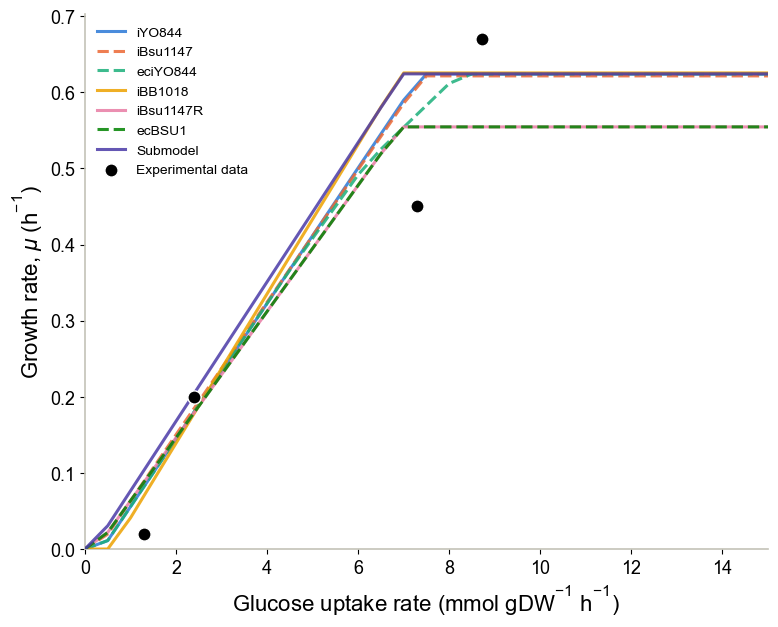

[INFO] Saved to ../results/figures\qGlc_vs_mu.pdf


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    # Math in labels ($\mu$, h$^{-1}$) otherwise renders in matplotlib's default DejaVu while
    # the surrounding text is Arial, so one axis label ends up in two typefaces.
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 11,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.linewidth": 1.2,
    "axes.edgecolor": "#c3c2b7",
    "pdf.fonttype": 42,
})

df = pd.read_csv("../results/tables/PhPP.csv")

model_order = ["iYO844", "iBsu1147", "eciYO844", "iBB1018", "iBsu1147R", "ecBSU1", "Submodel"]
model_order = [m for m in model_order if m in df["Model"].unique()]

# Fixed categorical order (dataviz skill palette, light mode) - never cycled/reassigned
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
dashed_models = {"iBsu1147", "eciYO844", "ecBSU1"}

fig, ax = plt.subplots(figsize=(8, 6.5))

for i, model in enumerate(model_order):
    subset = df[df["Model"] == model].sort_values("Glucose_uptake")
    ax.plot(
        subset["Glucose_uptake"],
        subset["Growth_rate"],
        linewidth=2.2,
        linestyle="--" if model in dashed_models else "-",
        color=colors[i % len(colors)],
        alpha=0.85,
        label=model,
        zorder=3 + i,
    )

# --- Experimental data (Chubukov et al., 2013 chemostat points) ---
experimental_qs = [8.71, 7.3, 2.4, 1.3]
experimental_mu = [0.67, 0.45, 0.2, 0.02]

ax.scatter(
    experimental_qs,
    experimental_mu,
    color="black",
    marker="o",
    s=90,
    edgecolor="white",
    linewidth=1.0,
    zorder=20,
    label="Experimental data",
)

ax.set_xlabel(r"Glucose uptake rate (mmol gDW$^{-1}$ h$^{-1}$)")
ax.set_ylabel(r"Growth rate, $\mu$ (h$^{-1}$)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(0, 15)
ax.set_ylim(bottom=0)

ax.legend(frameon=False, loc="upper left", fontsize=10, ncol=1)

plt.tight_layout()

figures_dir = "../results/figures"
os.makedirs(figures_dir, exist_ok=True)
out_path = os.path.join(figures_dir, "qGlc_vs_mu.pdf")
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"[INFO] Saved to {out_path}")

---

# Part 2 - the full glucose x oxygen plane

True phenotype phase planes in the sense of Edwards, Ibarra & Palsson: both uptake rates that
define the plane are swept over a grid while every other medium bound stays at its M9 value, so
each node is the same organism under the same medium at a different substrate supply.

`set_culture_media` and `refresh_solver` are reused from Part 1 rather than redefined. Note that
oxygen is *not* released here - it is the variable under study.

**Outputs** (PDF, in `../results/figures/3d_PhPP/`): one surface per model, a small-multiple panel
with a shared scale, and the same surfaces as filled contour maps with phase boundaries. The raw
grid goes to `../results/tables/PhPP_3D_grid.csv`.

## Setup

In [3]:
import os

import numpy as np
import pandas as pd
from cobra.io import read_sbml_model

DATA_DIR = os.path.join("..", "data")
FINAL_DIR = os.path.join(DATA_DIR, "models", "02_final_annotated")
FIGURES_DIR = os.path.join("..", "results", "figures", "3d_PhPP")
TABLES_DIR = os.path.join("..", "results", "tables")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

# iBsu1103, iBsu1103v2, iBsu1209 excluded from analysis notebooks 03+ (see PROJECT_CONTEXT.md)
MODEL_NAMES = ["iYO844", "iBsu1147", "eciYO844", "iBB1018", "iBsu1147R", "ecBSU1", "Submodel"]

GLC_ID, O2_ID = "EX_glc__D_e", "EX_o2_e"

# Ranges bracket the M9 operating point on both axes, so all three regimes are visible.
GLC_MAX, O2_MAX = 15.0, 30.0
N_GLC, N_O2 = 41, 41

medium = pd.read_csv(os.path.join(DATA_DIR, "datasets", "M9_media.csv"))

# The M9 operating point, marked on every plot for reference.
M9_GLC = -float(medium.loc[medium["ID"] == GLC_ID, "LOWER_BOUND"].iloc[0])
M9_O2 = -float(medium.loc[medium["ID"] == O2_ID, "LOWER_BOUND"].iloc[0])

glc_axis = np.linspace(0.0, GLC_MAX, N_GLC)
o2_axis = np.linspace(0.0, O2_MAX, N_O2)

print(f"[INFO] M9 operating point: {M9_GLC:.2f} mmol/gDW/h glucose, {M9_O2:.2f} mmol/gDW/h oxygen")
print(f"[INFO] Grid: {N_GLC} x {N_O2} = {N_GLC * N_O2} FBA solves per model, "
      f"{N_GLC * N_O2 * len(MODEL_NAMES)} total")

[INFO] M9 operating point: 8.70 mmol/gDW/h glucose, 18.00 mmol/gDW/h oxygen
[INFO] Grid: 41 x 41 = 1681 FBA solves per model, 11767 total


## Scan the plane

Only the two lower bounds move; the medium is otherwise fixed at M9, so every point on the
surface is the same organism under the same medium at a different substrate supply. The oxygen
exchange is import-only after M9 is applied (upper bound 0), so its lower bound alone sets the
supply. Glucose keeps its M9 upper bound, i.e. secretion stays allowed.

Infeasible nodes (no flux distribution satisfies the bounds) are recorded as `mu = 0` rather
than dropped, so the grid stays rectangular and the zero-growth region is drawn explicitly.

**Why the solver is refreshed on zero answers.** A grid scan re-solves the same LP a couple of
thousand times with only two bounds moving, and the solver keeps warm-start state between
solves. On the enzyme-constrained `ecBSU1` that state degrades partway through the scan and the
solver starts returning *status `optimal`, objective exactly 0* for bounds that in fact support
growth - and keeps returning it for every later point, so a whole block of the plane silently
collapses to zero. It is not infeasibility and there is no warning; the only tell is that growth
stops being monotonic in the uptake bounds. Every zero (real or not) is therefore re-checked once
on a refreshed problem, and the finished grid is audited for monotonicity below.

In [4]:
ZERO_TOL = 1e-9

surfaces = {}
records = []

for name in MODEL_NAMES:
    model = read_sbml_model(os.path.join(FINAL_DIR, f"{name}.xml"))
    set_culture_media(model, medium)

    rxn_glc = model.reactions.get_by_id(GLC_ID)
    rxn_o2 = model.reactions.get_by_id(O2_ID)

    # mu[i, j] -> oxygen index i (rows), glucose index j (columns)
    mu = np.zeros((N_O2, N_GLC))
    n_infeasible = 0
    n_recovered = 0

    for j, q_glc in enumerate(glc_axis):
        for i, q_o2 in enumerate(o2_axis):
            rxn_glc.lower_bound = -q_glc
            rxn_o2.lower_bound = -q_o2
            value = model.slim_optimize()

            if value is None or np.isnan(value) or value <= ZERO_TOL:
                refresh_solver(model)
                retry = model.slim_optimize()
                if retry is not None and not np.isnan(retry) and retry > ZERO_TOL:
                    n_recovered += 1
                value = retry

            if value is None or np.isnan(value) or value < 0:
                n_infeasible += 1
                value = 0.0

            mu[i, j] = value
            records.append({"Model": name, "Glucose_uptake": q_glc,
                            "Oxygen_uptake": q_o2, "Growth_rate": value})

    surfaces[name] = mu
    at_m9 = mu[int(np.argmin(abs(o2_axis - M9_O2))), int(np.argmin(abs(glc_axis - M9_GLC)))]
    notes = []
    if n_infeasible:
        notes.append(f"{n_infeasible} infeasible nodes -> 0")
    if n_recovered:
        notes.append(f"{n_recovered} stale-solver zeros recovered")
    suffix = f" ({'; '.join(notes)})" if notes else ""
    print(f"[OK] {name}: max mu = {mu.max():.4f} h-1, mu at M9 point = {at_m9:.4f} h-1{suffix}")

grid_df = pd.DataFrame(records)
grid_path = os.path.join(TABLES_DIR, "PhPP_3D_grid.csv")
grid_df.to_csv(grid_path, index=False)
print(f"\n[INFO] {len(grid_df)} rows written to {grid_path}")

[OK] iYO844: max mu = 0.6242 h-1, mu at M9 point = 0.6059 h-1 (61 infeasible nodes -> 0)


'' is not a valid SBML 'SId'.


[OK] iBsu1147: max mu = 0.6215 h-1, mu at M9 point = 0.5912 h-1 (44 infeasible nodes -> 0)


[OK] eciYO844: max mu = 0.6242 h-1, mu at M9 point = 0.5959 h-1 (123 infeasible nodes -> 0)


[OK] iBB1018: max mu = 0.6254 h-1, mu at M9 point = 0.6254 h-1 (125 infeasible nodes -> 0)


'' is not a valid SBML 'SId'.


[OK] iBsu1147R: max mu = 0.5546 h-1, mu at M9 point = 0.5546 h-1 (47 infeasible nodes -> 0)


'' is not a valid SBML 'SId'.


[OK] ecBSU1: max mu = 0.5546 h-1, mu at M9 point = 0.5546 h-1 (47 infeasible nodes -> 0)


[OK] Submodel: max mu = 0.6242 h-1, mu at M9 point = 0.6242 h-1 (47 infeasible nodes -> 0)

[INFO] 11767 rows written to ..\results\tables\PhPP_3D_grid.csv


### Monotonicity audit

Growth can only stay level or rise when a substrate bound is loosened, so `mu` must be
non-decreasing along both axes. Anything beyond LP tolerance here means a node is still wrong,
not that the model is interesting.

In [5]:
TOLERANCE_NOISE = 1e-3   # LP feasibility tolerance, not a modelling result

for name, mu in surfaces.items():
    drops = np.concatenate([np.diff(mu, axis=0).ravel(), np.diff(mu, axis=1).ravel()])
    worst = float(drops.min())
    if worst >= -TOLERANCE_NOISE:
        verdict = "OK" if worst >= 0 else f"OK (worst dip {worst:.1e}, within LP tolerance)"
    else:
        verdict = f"CHECK - worst dip {worst:.2e} exceeds LP tolerance"
    print(f"  {name:<10s} {verdict}")

  iYO844     OK (worst dip -2.2e-14, within LP tolerance)
  iBsu1147   OK (worst dip -5.7e-14, within LP tolerance)
  eciYO844   OK (worst dip -2.7e-04, within LP tolerance)
  iBB1018    OK (worst dip -1.9e-13, within LP tolerance)
  iBsu1147R  OK (worst dip -1.6e-07, within LP tolerance)
  ecBSU1     OK (worst dip -2.0e-14, within LP tolerance)
  Submodel   OK (worst dip -6.6e-14, within LP tolerance)


## Phase-plane geometry

Two features are read off each surface and drawn on the plots:

- **Line of optimality** - the ridge of the plane. For each glucose uptake it is the smallest
  oxygen uptake that already reaches 99% of the growth attainable at that glucose level. Below
  it the cell is oxygen-limited (growth still rises with oxygen); above it it is glucose-limited
  (the surface has flattened). Its slope through the origin is the model's optimal
  O2:glucose uptake ratio.

  The line is only defined while glucose still limits growth. Past glucose saturation the whole
  plane is flat, "the smallest oxygen reaching the column maximum" starts *falling* again, and
  continuing the line would draw a descending ridge that does not exist - so the scan stops at
  the first glucose level reaching the model's overall maximum.
- **Zero-growth boundary** - the contour where the surface leaves zero, i.e. the minimum
  supply of each substrate that permits any growth at all (maintenance demand).

In [6]:
RIDGE_TOL = 0.01        # "already at the column maximum" band
SATURATION_TOL = 0.005  # "glucose has stopped limiting" band


def line_of_optimality(mu, tol=RIDGE_TOL, saturation_tol=SATURATION_TOL):
    """Ridge of the phase plane over the glucose-limited range. Returns (glucose, oxygen, mu)."""
    column_max = mu.max(axis=0)
    overall = float(column_max.max())
    if overall <= ZERO_TOL:
        return np.array([]), np.array([]), np.array([])

    saturated = np.flatnonzero(column_max >= (1.0 - saturation_tol) * overall)
    j_end = int(saturated[0]) if len(saturated) else len(glc_axis) - 1

    q_glc, q_o2, q_mu = [], [], []
    for j in range(j_end + 1):
        column = mu[:, j]
        best = column.max()
        if best <= ZERO_TOL:
            continue
        i = int(np.argmax(column >= (1.0 - tol) * best))
        q_glc.append(glc_axis[j])
        q_o2.append(o2_axis[i])
        q_mu.append(column[i])
    return np.array(q_glc), np.array(q_o2), np.array(q_mu)


def optimal_uptake_ratio(lo_glc, lo_o2):
    """Least-squares slope of the ridge through the origin: mol O2 consumed per mol glucose."""
    keep = lo_glc > 0
    if keep.sum() < 2:
        return np.nan
    return float((lo_glc[keep] * lo_o2[keep]).sum() / (lo_glc[keep] ** 2).sum())


lo_summary = []
for name, mu in surfaces.items():
    lo_g, lo_o, _ = line_of_optimality(mu)
    lo_summary.append({
        "Model": name,
        "Max_growth_rate": float(mu.max()),
        "Glucose_saturation": float(lo_g.max()) if len(lo_g) else np.nan,
        "Optimal_O2_per_glucose": optimal_uptake_ratio(lo_g, lo_o),
    })

lo_df = pd.DataFrame(lo_summary).sort_values("Max_growth_rate", ascending=False)
lo_df.round(3)

,Model,Max_growth_rate,Glucose_saturation,Optimal_O2_per_glucose
3,iBB1018,0.625,7.125,2.752
6,Submodel,0.624,7.125,2.662
0,iYO844,0.624,7.500,2.874
2,eciYO844,0.624,8.250,2.752
1,iBsu1147,0.622,7.500,3.124
4,iBsu1147R,0.555,7.125,2.730
5,ecBSU1,0.555,7.125,2.730


## Plot style

Growth rate is a magnitude, so it is encoded with a single-hue sequential ramp that runs
light -> dark (blue), not a rainbow map. The line of optimality is drawn in the contrasting
categorical orange so it never reads as part of the growth scale.

In [7]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

plt.rcParams.update({
    "font.size": 11,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    # Math in labels ($\mu$, h$^{-1}$) otherwise renders in matplotlib's default DejaVu while
    # the surrounding text is Arial, so one axis label ends up in two typefaces.
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.0,
    "axes.edgecolor": "#c3c2b7",
    "pdf.fonttype": 42,   # keep text as text in the PDF, not outlines
    "savefig.transparent": False,
})

# Sequential blue ramp, light -> dark (100 -> 700 steps)
BLUE_RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
             "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
PHPP_CMAP = LinearSegmentedColormap.from_list("phpp_blue", BLUE_RAMP)

LO_COLOR = "#eb6834"      # line of optimality
M9_COLOR = "#0b0b0b"      # M9 operating point
GRID_COLOR = "#e1e0d9"
MUTED = "#52514e"

XLABEL = r"Glucose uptake (mmol gDW$^{-1}$ h$^{-1}$)"
YLABEL = r"Oxygen uptake (mmol gDW$^{-1}$ h$^{-1}$)"
ZLABEL = r"Growth rate, $\mu$ (h$^{-1}$)"

GLC_MESH, O2_MESH = np.meshgrid(glc_axis, o2_axis)


def style_3d_axes(ax):
    """Recessive panes and grid so the surface carries the figure."""
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor("white")
        axis.pane.set_edgecolor(GRID_COLOR)
        axis.pane.set_alpha(1.0)
        axis._axinfo["grid"].update(color=GRID_COLOR, linewidth=0.6)
    ax.tick_params(colors=MUTED, pad=0)


def draw_surface(ax, mu, zmax, mesh_lines=True, show_optimality=True, show_m9=True):
    """One 3D growth surface, optionally annotated with its ridge and the M9 operating point."""
    norm = Normalize(vmin=0.0, vmax=zmax)
    ax.plot_surface(GLC_MESH, O2_MESH, mu, cmap=PHPP_CMAP, norm=norm,
                    rstride=1, cstride=1, linewidth=0.15 if mesh_lines else 0,
                    edgecolors="#ffffff", antialiased=True, shade=False)
    # Same field projected onto the floor, so the phase regions are readable head-on too
    ax.contourf(GLC_MESH, O2_MESH, mu, levels=12, cmap=PHPP_CMAP, norm=norm,
                zdir="z", offset=0.0, alpha=0.45)

    if show_optimality:
        lo_g, lo_o, lo_mu = line_of_optimality(mu)
        if len(lo_g):
            ax.plot(lo_g, lo_o, lo_mu, color=LO_COLOR, linewidth=2.2, label="Line of optimality")

    if show_m9:
        j = int(np.argmin(abs(glc_axis - M9_GLC)))
        i = int(np.argmin(abs(o2_axis - M9_O2)))
        ax.plot([M9_GLC, M9_GLC], [M9_O2, M9_O2], [0.0, mu[i, j]],
                color=M9_COLOR, linewidth=1.0, linestyle=":")
        # Lifted a hair off the surface: matplotlib's 3D renderer has no true depth buffer, and
        # a marker sitting exactly on the surface it belongs to gets painted over half the time.
        ax.scatter([M9_GLC], [M9_O2], [mu[i, j] + 0.02 * zmax], color=M9_COLOR, s=36,
                   depthshade=False, edgecolor="white", linewidth=0.8, label="M9 medium")

    ax.set_xlim(0, GLC_MAX)
    ax.set_ylim(0, O2_MAX)
    ax.set_zlim(0, zmax)
    ax.view_init(elev=26, azim=-52)
    ax.set_box_aspect((1, 1, 0.62), zoom=0.94)
    style_3d_axes(ax)

## One surface per model

`bbox_inches="tight"` is not used on these: matplotlib's tight bounding box doesn't account for
a 3D axes' rotated tick and axis labels, and clips them. Explicit margins instead.

In [8]:
for name, mu in surfaces.items():
    fig = plt.figure(figsize=(7.4, 5.8))
    ax = fig.add_subplot(111, projection="3d")

    draw_surface(ax, mu, max(float(mu.max()), 1e-3))
    ax.set_xlabel(XLABEL, labelpad=10, color=MUTED)
    ax.set_ylabel(YLABEL, labelpad=10, color=MUTED)
    ax.set_zlabel(ZLABEL, labelpad=6, color=MUTED)
    ax.set_title(name, fontweight="bold", pad=0)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.02, 0.92), fontsize=9)
    fig.subplots_adjust(left=0.02, right=0.95, bottom=0.09, top=0.95)

    out_path = os.path.join(FIGURES_DIR, f"PhPP_3D_{name}.pdf")
    fig.savefig(out_path)
    plt.close(fig)
    print(f"[INFO] Saved {out_path}")

[INFO] Saved ..\results\figures\3d_PhPP\PhPP_3D_iYO844.pdf


[INFO] Saved ..\results\figures\3d_PhPP\PhPP_3D_iBsu1147.pdf


[INFO] Saved ..\results\figures\3d_PhPP\PhPP_3D_eciYO844.pdf


[INFO] Saved ..\results\figures\3d_PhPP\PhPP_3D_iBB1018.pdf


[INFO] Saved ..\results\figures\3d_PhPP\PhPP_3D_iBsu1147R.pdf


[INFO] Saved ..\results\figures\3d_PhPP\PhPP_3D_ecBSU1.pdf


[INFO] Saved ..\results\figures\3d_PhPP\PhPP_3D_Submodel.pdf


## All models on one shared scale

Same surfaces, one common growth-rate scale and one common colour scale, so panel height and
colour are comparable across models rather than each panel being self-normalised.

The line of optimality and the M9 point are deliberately left off here - at this size they
clutter the surfaces without being readable. Both are in the contour view below, which is where
they are meant to be compared between models anyway.

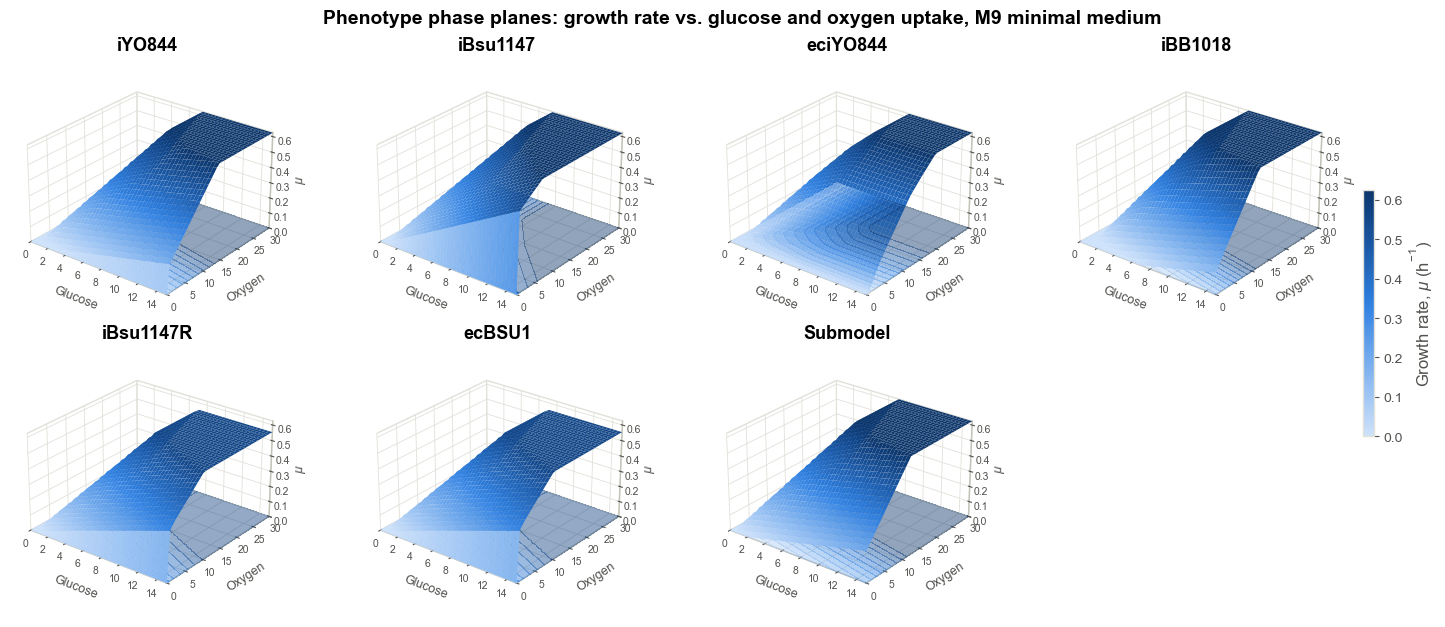

[INFO] Saved ..\results\figures\3d_PhPP\PhPP_3D_all_models.pdf


In [9]:
n_models = len(surfaces)
n_cols = 4
n_rows = int(np.ceil(n_models / n_cols))
ZMAX = float(max(mu.max() for mu in surfaces.values()))

fig = plt.figure(figsize=(4.0 * n_cols, 3.2 * n_rows))

for k, (name, mu) in enumerate(surfaces.items()):
    ax = fig.add_subplot(n_rows, n_cols, k + 1, projection="3d")
    # No white mesh lines at this size - at 41 x 41 they would swamp the surface colour
    draw_surface(ax, mu, ZMAX, mesh_lines=False, show_optimality=False, show_m9=False)
    ax.set_title(name, fontweight="bold", pad=-6)
    ax.set_xlabel("Glucose", labelpad=-2, fontsize=9, color=MUTED)
    ax.set_ylabel("Oxygen", labelpad=-2, fontsize=9, color=MUTED)
    ax.set_zlabel(r"$\mu$", labelpad=-8, fontsize=9, color=MUTED)
    ax.tick_params(labelsize=7.5, pad=-3)

mappable = cm.ScalarMappable(norm=Normalize(vmin=0.0, vmax=ZMAX), cmap=PHPP_CMAP)
cbar = fig.colorbar(mappable, ax=fig.axes, fraction=0.015, pad=0.035, shrink=0.5, aspect=24)
cbar.set_label(ZLABEL, color=MUTED)
cbar.outline.set_edgecolor(GRID_COLOR)
cbar.ax.tick_params(colors=MUTED)

fig.suptitle("Phenotype phase planes: growth rate vs. glucose and oxygen uptake, M9 minimal medium",
             fontsize=14, fontweight="bold", y=0.97)
fig.subplots_adjust(left=0.0, right=0.87, bottom=0.02, top=0.90, wspace=0.02, hspace=0.05)

out_path = os.path.join(FIGURES_DIR, "PhPP_3D_all_models.pdf")
fig.savefig(out_path)
plt.show()
print(f"[INFO] Saved {out_path}")

## Contour view

The same surfaces seen from above. Reading the phase regions - where growth is oxygen-limited,
where it is glucose-limited, and where the model does not grow at all - is easier here than on
the 3D surface, and the slope of the line of optimality is directly comparable between models.

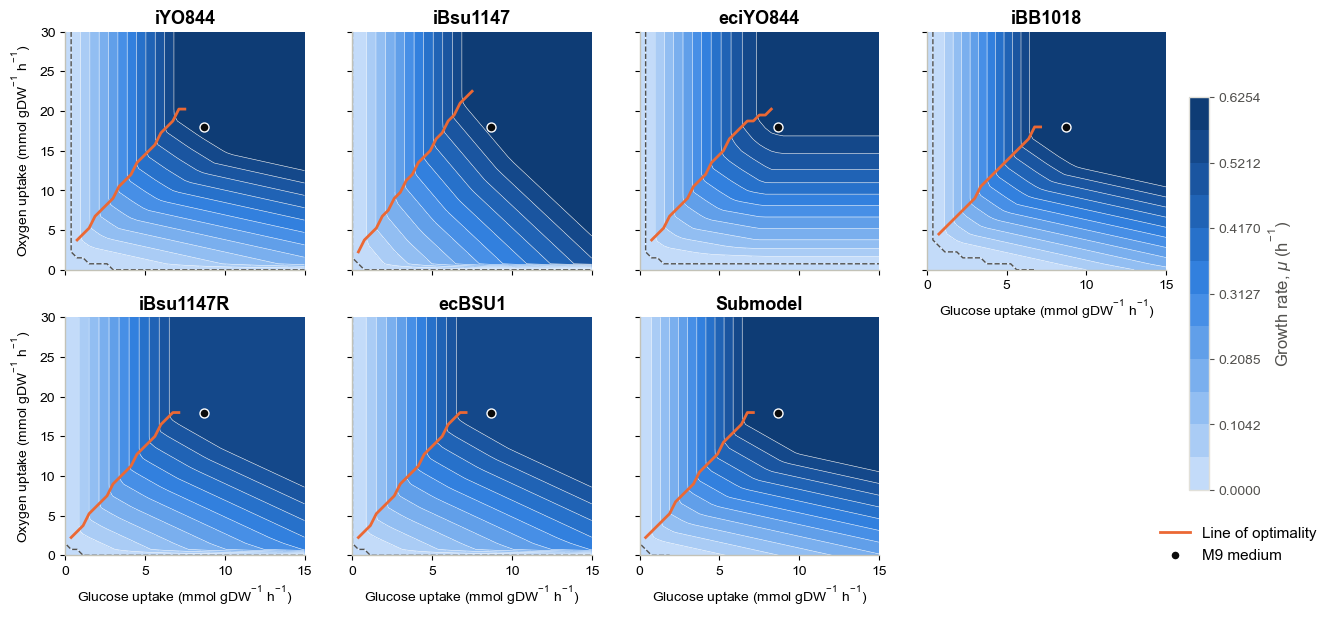

[INFO] Saved ..\results\figures\3d_PhPP\PhPP_contour_all_models.pdf


In [10]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.7 * n_cols, 3.4 * n_rows),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

levels = np.linspace(0.0, ZMAX, 13)

for ax, (name, mu) in zip(axes, surfaces.items()):
    filled = ax.contourf(GLC_MESH, O2_MESH, mu, levels=levels, cmap=PHPP_CMAP, extend="neither")
    ax.contour(GLC_MESH, O2_MESH, mu, levels=levels, colors="white", linewidths=0.4)
    # Zero-growth boundary: the edge of the no-growth region
    ax.contour(GLC_MESH, O2_MESH, mu, levels=[1e-6], colors=[MUTED], linewidths=1.0,
               linestyles="--")

    lo_g, lo_o, _ = line_of_optimality(mu)
    if len(lo_g):
        ax.plot(lo_g, lo_o, color=LO_COLOR, linewidth=2.0, label="Line of optimality")
    ax.scatter([M9_GLC], [M9_O2], color=M9_COLOR, s=42, edgecolor="white", linewidth=1.0,
               zorder=6, label="M9 medium")

    ax.set_title(name, fontweight="bold")
    ax.set_xlim(0, GLC_MAX)
    ax.set_ylim(0, O2_MAX)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

for ax in axes[len(surfaces):]:
    ax.set_visible(False)

# Axis labels on outer edges only; a panel above an empty slot counts as outer.
grid_axes = axes.reshape(n_rows, n_cols)
for r in range(n_rows):
    for c in range(n_cols):
        index = r * n_cols + c
        if index >= len(surfaces):
            continue
        ax = grid_axes[r, c]
        if index + n_cols >= len(surfaces):
            ax.set_xlabel(XLABEL, fontsize=10)
            ax.tick_params(labelbottom=True)
        if c == 0:
            ax.set_ylabel(YLABEL, fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc="lower right", bbox_to_anchor=(0.98, 0.08),
           fontsize=11)

cbar = fig.colorbar(filled, ax=list(axes), fraction=0.02, pad=0.02, shrink=0.75)
cbar.set_label(ZLABEL, color=MUTED)
cbar.outline.set_edgecolor(GRID_COLOR)
cbar.ax.tick_params(colors=MUTED)

out_path = os.path.join(FIGURES_DIR, "PhPP_contour_all_models.pdf")
fig.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"[INFO] Saved {out_path}")

## Summary

In [11]:
summary = lo_df.copy()
summary["mu at M9 point"] = [
    surfaces[m][int(np.argmin(abs(o2_axis - M9_O2))), int(np.argmin(abs(glc_axis - M9_GLC)))]
    for m in summary["Model"]
]
summary = summary.rename(columns={
    "Max_growth_rate": "max mu over grid (h-1)",
    "Glucose_saturation": "glucose saturation (mmol/gDW/h)",
    "Optimal_O2_per_glucose": "optimal O2:glucose ratio",
})
summary.round(3).reset_index(drop=True)

,Model,max mu over grid (h-1),glucose saturation (mmol/gDW/h),optimal O2:glucose ratio,mu at M9 point
0,iBB1018,0.625,7.125,2.752,0.625
1,Submodel,0.624,7.125,2.662,0.624
2,iYO844,0.624,7.500,2.874,0.606
3,eciYO844,0.624,8.250,2.752,0.596
4,iBsu1147,0.622,7.500,3.124,0.591
5,iBsu1147R,0.555,7.125,2.730,0.555
6,ecBSU1,0.555,7.125,2.730,0.555
